This notebooks uses NLP teachniques with machine learning to classift SMS messages as either spam or ham


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import string
import re

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score, precision_score, f1_score

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/BuhariS/spam_sms_collection/refs/heads/main/sms_spam_collection.csv")

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
# Check the distribution of the labels
class_counts = df["label"].value_counts()
class_counts

label
ham     4825
spam     747
Name: count, dtype: int64

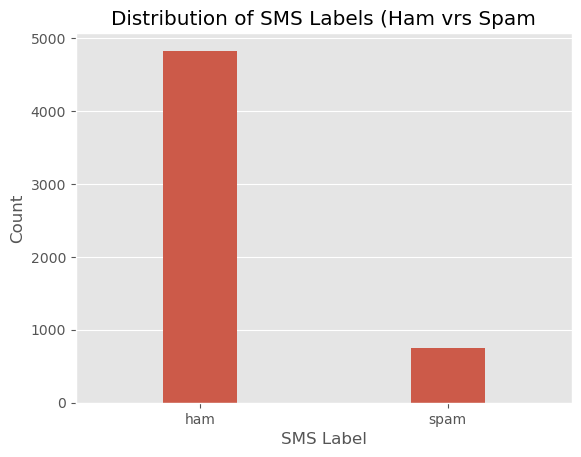

In [4]:
# Plot a bar chart of the class counts
fig, ax = plt.subplots()

sns.countplot(x = df["label"],
              width = 0.3,
              ax = ax)

ax.set(title = "Distribution of SMS Labels (Ham vrs Spam",
       xlabel = "SMS Label",
       ylabel = "Count")

plt.show()

In [5]:
# Replace hamham with 0 and spam with 1 to make it suitable for machine learning
df["label"] = df["label"].map({"ham" : 0, "spam": 1})
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
# remove punctuations
def remove_punctuation(text):

    return "".join(char for char in text if char not in string.punctuation)

df["message"] = (df["message"]
                 .str.lower()
                 .apply(remove_punctuation)
                )

In [7]:
# check the changes

df.head()

,label,message
0,0,go until jurong point crazy available only in ...
1,0,ok lar joking wif u oni
2,1,free entry in 2 a wkly comp to win fa cup fina...
3,0,u dun say so early hor u c already then say
4,0,nah i dont think he goes to usf he lives aroun...


In [8]:
X = df["message"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2, 
                                                    # stratify = y,
                                                    random_state = 42)

In [9]:
# Use the count vectorizer
stopwords_list = stopwords.words("English")

count_vectorizer = CountVectorizer(stop_words = stopwords_list,
                                  ngram_range = (1, 2),
                                  max_features = 2500
                                  )

X_train_count_vect = count_vectorizer.fit_transform(X_train)

X_test_count = count_vectorizer.transform(X_test)

In [10]:
# instantiate and fit a logistic regression model
model = LogisticRegression(C=10)

model.fit(X_train_count_vect, y_train)

y_preds = model.predict(X_test_count)

In [11]:
# visualise the confusin matrix to see model performance

def visualise_confusion_matrix(y_test, y_preds, title):
    
    fig, ax = plt.subplots()

    sns.heatmap(confusion_matrix(y_test, y_preds), 
                annot = True, 
                fmt=".0f", 
                cbar=False,
                xticklabels=["ham", "spam"],
                yticklabels=["ham", "spam"],
                cmap="coolwarm",
                ax = ax
                )
    
    ax.set_title(title)
    ax.set_xlabel("Predictions")
    ax.set_ylabel("Actuals")
    plt.show()

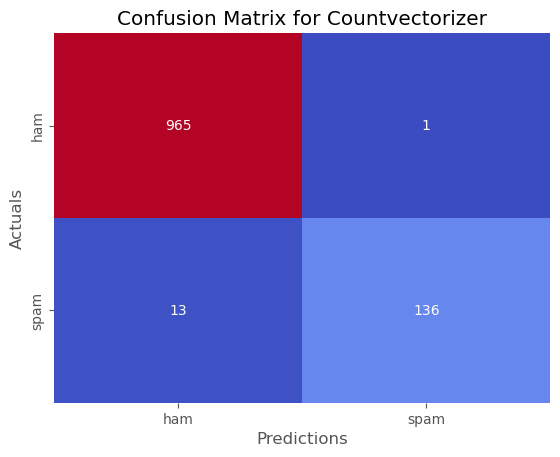

In [12]:
# visualise the confusin matrix to see model performance
visualise_confusion_matrix(y_test, y_preds, "Confusion Matrix for Countvectorizer")

In [13]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       966
           1       0.99      0.91      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115



In [14]:
# Instantiate the vectorizer
stopwords_list = stopwords.words("English")

vectorizer = TfidfVectorizer(
                lowercase = True,
                stop_words = stopwords_list,
                ngram_range = (1,2),
                max_features = 2500
               )

X_train_vect = vectorizer.fit_transform(X_train)

X_test_vect = vectorizer.transform(X_test)

In [15]:
# Train a logistic regression
# lr = LogisticRegression()

model.fit(X_train_vect, y_train)

y_preds = model.predict(X_test_vect)

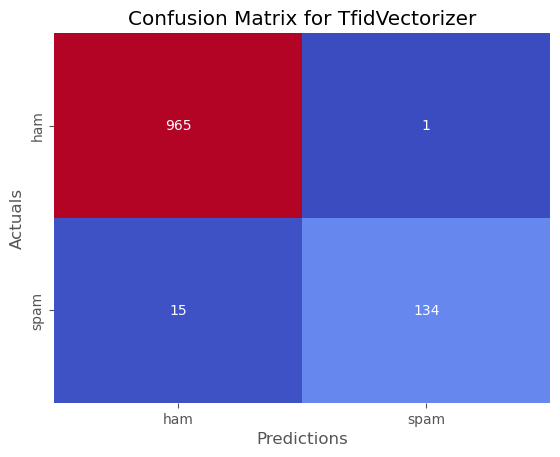

In [16]:
# plot a heatmap of the confusion matrix
visualise_confusion_matrix(y_test, y_preds, "Confusion Matrix for TfidVectorizer")

In [17]:
# Check the performance of the model
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       0.99      0.90      0.94       149

    accuracy                           0.99      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.99      0.99      0.99      1115



In [18]:
# Test the model on fresh data
new_messages = [
    "Frank you have just won 3 million, click the link to claim it",
    "I love you so much"
]

new_vect = vectorizer.transform(new_messages)

predictions = model.predict(new_vect)

for msg, pred in zip(new_messages, predictions):
    print(f"Message: {msg}")
    print("Prediction:", "Spam" if pred == 1 else "Ham")
    print()

Message: Frank you have just won 3 million, click the link to claim it
Prediction: Spam

Message: I love you so much
Prediction: Ham



In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators = 100, 
                            max_depth = 100,
                            random_state = 42
                           )

rf.fit(X_train_count_vect, y_train)

preds = rf.predict(X_test_count)

print(confusion_matrix(y_test, preds), "\n")
print(classification_report(y_test, preds))

[[966   0]
 [ 24 125]] 

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       1.00      0.84      0.91       149

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [20]:
# fit the random forest on the tfid vectorised data
rf.fit(X_train_vect, y_train)

preds = rf.predict(X_test_vect)

print(confusion_matrix(y_test, preds))

[[966   0]
 [ 25 124]]


In [21]:
# training and predicting a decision tree classifier on the tfid vectorised data
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=200, random_state=94)

dt.fit(X_train_vect, y_train)

preds = dt.predict(X_test_vect)


print(confusion_matrix(y_test, preds))

[[948  18]
 [ 32 117]]


In [22]:
# train and predict on the count vectorised data
dt.fit(X_train_count_vect, y_train)
preds = dt.predict(X_test_count)

print(confusion_matrix(y_test, preds))

[[944  22]
 [ 25 124]]


In [23]:
from sklearn.svm import SVC

svc_model = SVC(kernel='rbf', C = 2.5, random_state=94)

svc_model.fit(X_train_count_vect, y_train)

svc_preds = svc_model.predict(X_test_count)

print(confusion_matrix(y_test, svc_preds))

[[966   0]
 [ 18 131]]


In [24]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()

knn_model.fit(X_train_count_vect, y_train)

knn_preds = knn_model.predict(X_test_count)

print(confusion_matrix(y_test, svc_preds))

[[966   0]
 [ 18 131]]


In [25]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train_count_vect.toarray(), y_train)

nb_preds = nb_model.predict(X_test_count.toarray())

print(confusion_matrix(y_test, nb_preds))

[[804 162]
 [ 11 138]]


In [26]:
# Define a helper function to train and assess model performances
np.random.seed(42)

def model_performance(models, X_train, y_train, X_test, y_test):

    metrics_df = pd.DataFrame(index = ["accuracy", "recall", "precision", "f1-score"])


    for model_name, model in models.items():

        performance_metrics = []
    
        model.fit(X_train, y_train)
        
        y_preds = model.predict(X_test)
        performance_metrics.append(round(accuracy_score(y_test, y_preds), 2))
        performance_metrics.append(round(recall_score(y_test, y_preds), 2))
        performance_metrics.append(round(precision_score(y_test, y_preds), 2))
        performance_metrics.append(round(f1_score(y_test, y_preds), 2))

        metrics_df[model_name] = performance_metrics

    # visualise the performance
    fig, ax = plt.subplots(figsize = (16, 9))     

    return metrics_df.plot.bar(ax = ax);

        

<Axes: >

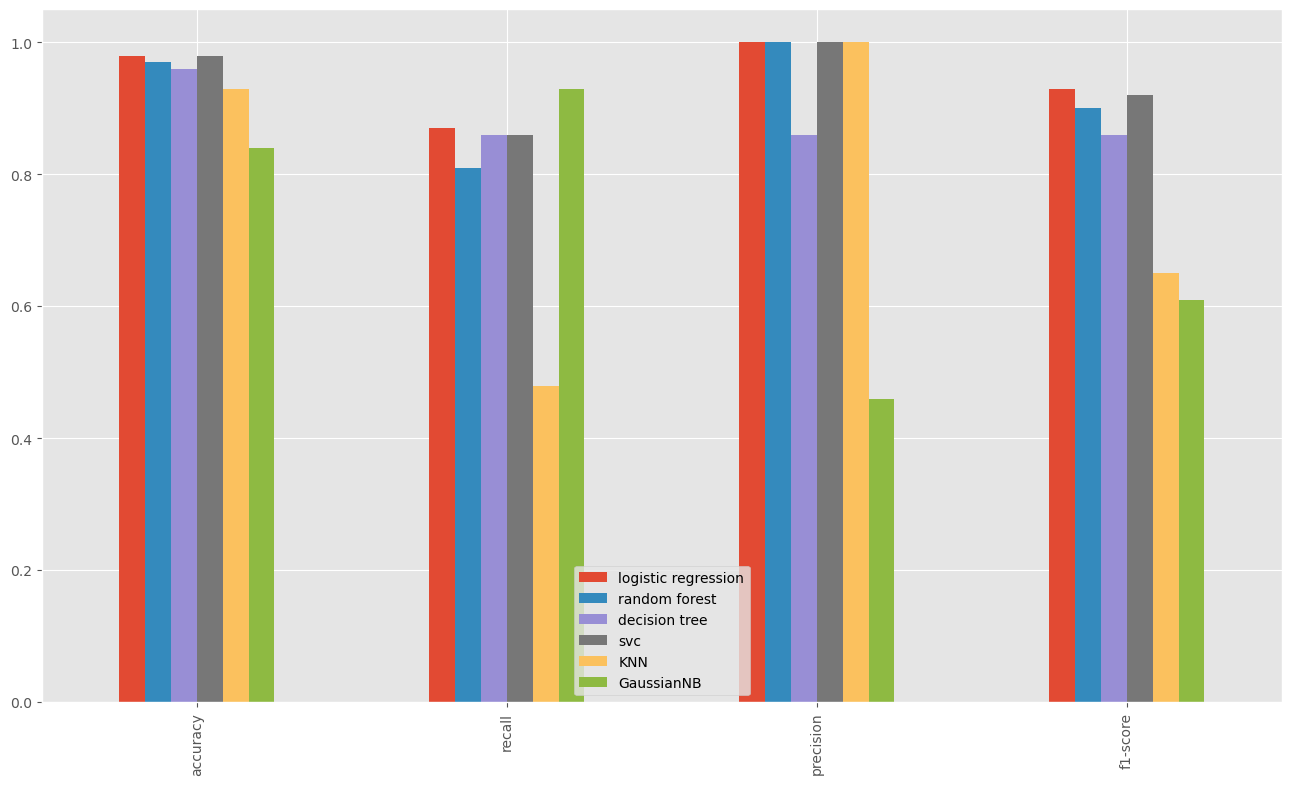

In [27]:
models = {
    'logistic regression': LogisticRegression(),
    'random forest' : RandomForestClassifier(),
    'decision tree' : DecisionTreeClassifier(),
    'svc' : SVC(),
    'KNN' : KNeighborsClassifier(),
    'GaussianNB' : GaussianNB()
}

# Test the model performance on the count-vectorised data

model_performance(models, X_train_count_vect.toarray(), y_train, X_test_count.toarray(), y_test)

<Axes: >

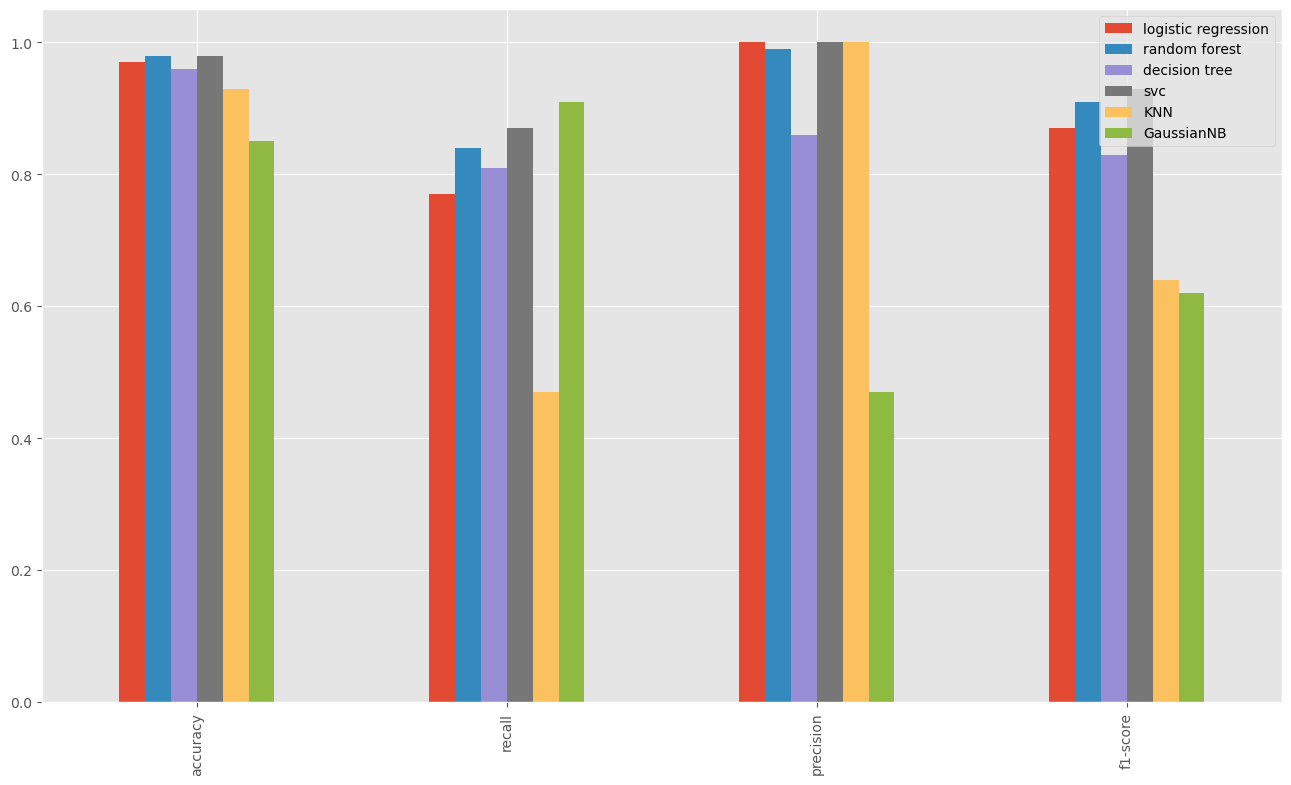

In [28]:
# test the performamnce on tdif vectorised data

model_performance(models, X_train_vect.toarray(), y_train, X_test_vect.toarray(), y_test)

In [29]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', {0:1, 1:5}]  # Critical for imbalance!
}

cv = StratifiedKFold(n_splits = 5, 
                     shuffle = True,
                     random_state = 42)

grid_search = GridSearchCV(estimator=RandomForestClassifier(),
                           param_grid = param_grid,
                           cv = cv,
                           scoring = 'f1',
                           n_jobs = -1,
                           verbose = 2)

grid_search.fit(X_train_vect, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'class_weight': ['balanced', {0: 1, 1: 5}],
                         'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='f1', verbose=2)

In [30]:
print(grid_search.best_params_)

{'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [31]:
print(grid_search.best_score_)

0.9103213856658448


In [32]:
# use the best estimator to make predictions

preds = grid_search.best_estimator_.predict(X_test_vect)

print(confusion_matrix(y_test, preds))
print(classification_report(y_test, preds))

[[966   0]
 [ 18 131]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       1.00      0.88      0.94       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [33]:
# do a grid search cV to see if the logistic regression model can be improved on the count_vectorised data
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],           # Regularization strength
    'penalty': ['l1', 'l2', 'elasticnet'],   # Regularization type
    # 'solver': ['liblinear', 'saga'],          # Compatible solvers
    # 'class_weight': ['balanced', {0:1, 1:5}] # Handle imbalance
}

grid_search = GridSearchCV(estimator = LogisticRegression(),
                          cv = cv,
                          param_grid = param_grid_lr,
                          scoring = 'f1', 
                          n_jobs = -1,
                          verbose = 2)

grid_search.fit(X_train_count_vect, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


c:\Users\AWENARE SUB 1\DS-Practice\env\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
50 fits failed out of a total of 75.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\AWENARE SUB 1\DS-Practice\env\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\AWENARE SUB 1\DS-Practice\env\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\AWENARE SUB 1\DS-Practice\env\Lib\site-packages\sklearn\line

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'penalty': ['l1', 'l2', 'elasticnet']},
             scoring='f1', verbose=2)

In [34]:
print(grid_search.best_score_)

0.9147040735439628


In [35]:
print(grid_search.best_params_)

{'C': 10, 'penalty': 'l2'}


In [36]:
lr_preds = grid_search.best_estimator_.predict(X_test_count)

print(confusion_matrix(y_test, lr_preds))
print(classification_report(y_test, lr_preds))

[[965   1]
 [ 13 136]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       966
           1       0.99      0.91      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115



## Using principal component analysis to improve model performance

I performed a dimensionality reducation using PCA to reduce the fetaures from 2500 to 250 and then trained the logistic regression model to compare results.

In [37]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# scale the data to ensure uniformity
scaler = StandardScaler(with_mean=False)

X_train_scaled = scaler.fit_transform(X_train_vect)
X_test_scaled = scaler.transform(X_test_vect)

# apply pca for dimensionality reduction
pca = PCA(n_components=250)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

250 features explains 44.14% of the variances in the training set


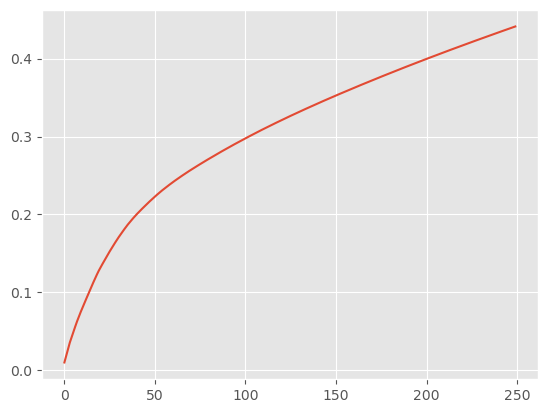

In [38]:
cum_explained_ratio = pca.explained_variance_ratio_.cumsum()
print(f"250 features explains {pca.explained_variance_ratio_.sum():.2%} of the variances in the training set")
plt.plot(np.arange(cum_explained_ratio.size),  cum_explained_ratio);

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       966
           1       0.97      0.95      0.96       149

    accuracy                           0.99      1115
   macro avg       0.98      0.97      0.98      1115
weighted avg       0.99      0.99      0.99      1115



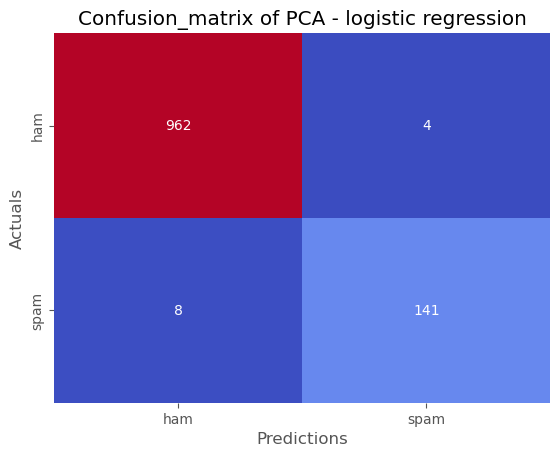

In [39]:
lr_model = LogisticRegression(C = 0.1)

lr_model.fit(X_train_pca, y_train)

preds = lr_model.predict(X_test_pca)
print(classification_report(y_test, preds))

visualise_confusion_matrix(y_test, preds, "Confusion_matrix of PCA - logistic regression")

With only 250 features out of 2500 (representing just 10% of the features), PCA has achieved better results that all other attempts at model improvements!

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       966
           1       0.96      0.88      0.92       149

    accuracy                           0.98      1115
   macro avg       0.97      0.94      0.95      1115
weighted avg       0.98      0.98      0.98      1115



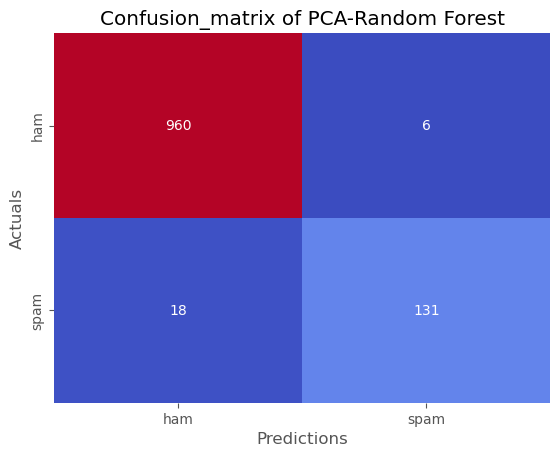

In [40]:
rf_model = RandomForestClassifier()

rf_model.fit(X_train_pca, y_train)

rf_preds = rf_model.predict(X_test_pca)

print(classification_report(y_test, rf_preds))

visualise_confusion_matrix(y_test, rf_preds, "Confusion_matrix of PCA-Random Forest")


Logistic regression outperformed random-forst using the reduced dimensions from pca

## Use downsizing techniques to attempt to improve model performance

In [41]:
from sklearn.utils import resample

X_train_pca_df = pd.DataFrame(X_train_pca)
X_train_pca_df['label'] = y_train

spam_sms = X_train_pca_df[X_train_pca_df['label'] == 1]
ham_sms = X_train_pca_df[X_train_pca_df['label'] == 0]

ham_down_sampled = resample(ham_sms,
                            replace =  False,
                            n_samples = len(spam_sms),
                            )

combined = pd.concat([spam_sms, ham_down_sampled]).sample(frac = 1, random_state = 42)

X_train_downsampled = combined.drop('label', axis = 1)
y_train_downsampled = combined['label']

combined['label'].value_counts()

label
1.0    481
0.0    481
Name: count, dtype: int64

              precision    recall  f1-score   support

           0       0.85      0.50      0.63       966
           1       0.12      0.44      0.19       149

    accuracy                           0.50      1115
   macro avg       0.49      0.47      0.41      1115
weighted avg       0.76      0.50      0.57      1115



c:\Users\AWENARE SUB 1\DS-Practice\env\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


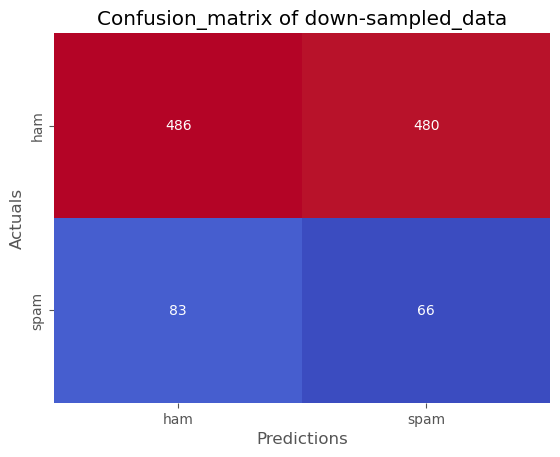

In [42]:
model = LogisticRegression()

model.fit(X_train_downsampled, y_train_downsampled)

preds = model.predict(X_test_pca)

print(classification_report(y_test, preds))

visualise_confusion_matrix(y_test, preds, "Confusion_matrix of down-sampled_data")


## Use up-sizing techniques to attempt to improve model performance

In [43]:

X_train_pca_df = pd.DataFrame(X_train_pca)
X_train_pca_df['label'] = y_train

spam_sms = X_train_pca_df[X_train_pca_df['label'] == 1]
ham_sms = X_train_pca_df[X_train_pca_df['label'] == 0]

spam_up_sampled = resample(spam_sms,
                            replace =  True,
                            n_samples = len(ham_sms),
                            random_state = 42
                            )

combined_df = pd.concat([ham_sms, spam_up_sampled]).sample(frac = 1, random_state = 42)

X_train_upsampled = combined_df.drop('label', axis = 1)
y_train_upsampled = combined['label']

combined['label'].value_counts()

label
1.0    481
0.0    481
Name: count, dtype: int64

c:\Users\AWENARE SUB 1\DS-Practice\env\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           0       0.85      0.50      0.63       966
           1       0.12      0.44      0.19       149

    accuracy                           0.50      1115
   macro avg       0.49      0.47      0.41      1115
weighted avg       0.76      0.50      0.57      1115



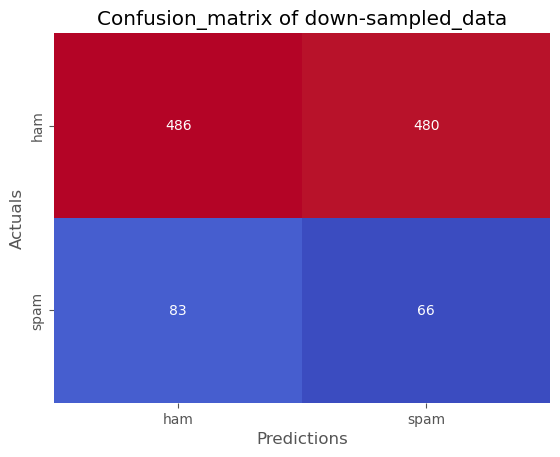

In [44]:
model = LogisticRegression()

model.fit(X_train_downsampled, y_train_downsampled)

preds = model.predict(X_test_pca)

print(classification_report(y_test, preds))

visualise_confusion_matrix(y_test, preds, "Confusion_matrix of down-sampled_data")



It appears that the up-sampling and down-sampling techniques even worsened the model performance.


